<a href="https://colab.research.google.com/github/Aaricis/Hung-yi-Lee-ML2022/blob/main/HW10/HW10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 思路
本次作业在JudgeBoi上提交，非台大的学生不能访问。出于学习的目的实现各种trick，仅供参考。

## Simple baseline (acc <= 0.70)

运行Sample Code。

fgsm_acc = 0.59000, fgsm_loss = 2.49187

## Medium baseline (acc <= 0.50)
根据助教提示，使用Ensemble Attack方法，攻击算法为IFGSM。

精度明显降低：

ifgsm_ensemble_acc = 0.00000, ifgsm_ensemble_loss = 2.45724

- 随机选择几个预训练模型：

```python
model_names = [
    'nin_cifar10',
    'resnet20_cifar10',
    'preresnet20_cifar10'
]
```
- 补全`class ensembleNet`。


```python
from pytorchcv.model_provider import get_model as ptcv_get_model

class ensembleNet(nn.Module):
  def __init__(self, model_names):
    super().__init__()
    self.models = nn.ModuleList([ptcv_get_model(name, pretrained=True) for name in model_names])
    self.softmax = nn.Softmax(dim=1)
  def forward(self, x):
    ensemble_logits = None
    for i, m in enumerate(self.models):
      # TODO: sum up logits from multiple models
      # return ensemble_logits
      logits = m(x)
      if ensemble_logits is None:
        ensemble_logits = logits
      else:
        ensemble_logits += logits

      ensemble_logits /= len(self.models)

    return self.softmax(ensemble_logits)
```
- 实现'Ensemble attack with IFGSM'；


```python
adv_examples, ifgsm_acc, ifgsm_loss = gen_adv_examples(ensemble_model, adv_loader, ifgsm, loss_fn)
print(f'ifgsm_ensemble_acc = {ifgsm_acc:.5f}, ifgsm_ensemble_loss = {ifgsm_loss:.5f}')

create_dir(root, 'ifgsm_ensemble', adv_examples, adv_names)
```






## Strong baseline (acc <= 0.30)
助教提供了两个思路：
1. Ensemble Attack + paper B (pick right models) + IFGSM
2. Ensemble Attack + many models + MIFGSM

Ensemble Attack与Medium Baseline相同。

思路1'paper B (pick right models)'使用了论文
[Query-Free Adversarial Transfer via Undertrained Surrogates](https://link.zhihu.com/?target=https%3A//arxiv.org/abs/2007.00806)的思想，旨在挑选更effective的单个代理模型，而不是随机的一组代理模型。论文定义了**Undertrained Models**，
它包含两个condition：
- 具有更高验证集损失；
- 训练的step或epoch更少；

可产生更强的可转移的对抗性攻击。

**实作中采用了思路2的方法。**

mifgsm_acc = 0.00000, mifgsm_loss = 2.36389

- 增加更多代理模型；


```python
model_names = [
    'nin_cifar10',
    'resnet20_cifar10',
    'resnet56_cifar10',
    'preresnet20_cifar10',
    'preresnet56_cifar10',
    'seresnet20_cifar10',
    'seresnet56_cifar10',
    'sepreresnet20_cifar10',
    'sepreresnet56_cifar10',
    'wrn16_10_cifar10',
    'wrn20_10_1bit_cifar10',
    'rir_cifar10',
    'diaresnet20_cifar10',
    'diapreresnet20_cifar10',
    'densenet40_k12_cifar10',
]
```

- 实现MIFGSM算法

MIFGSM（Momentum Iterative Fast Gradient Sign Method）对抗攻击算法是IFGSM引入动量的优化版本，使得攻击更稳定、迁移性更强。

```python
def mifgsm(model, x, y, loss_fn, epsilon=epsilon, alpha=alpha, num_iter=50, mu=1.0):
    x_adv = x
    # initialze momentum tensor
    momentum = torch.zeros_like(x).detach().to(device)
    # write a loop of num_iter to represent the iterative times
    for i in range(num_iter):
        x_adv = x_adv.detach().clone()
        x_adv.requires_grad = True # need to obtain gradient of x_adv, thus set required grad
        loss = loss_fn(model(x_adv), y) # calculate loss
        loss.backward() # calculate gradient

        # TODO: Momentum calculation
        grad = x_adv.grad.detach()
        # 梯度归一化（L1范数）
        grad_norm = torch.mean(torch.abs(grad), dim=(1, 2, 3), keepdim=True)
        normalized_grad = grad / (grad_norm + 1e-8)  # 避免除零
        grad = mu * momentum + normalized_grad
        momentum = grad

        x_adv = x_adv + alpha * grad.sign()
        x_adv = torch.max(torch.min(x_adv, x+epsilon), x-epsilon) # clip new x_adv back to [x-epsilon, x+epsilon]
    return x_adv
```



## Boss baseline (acc <= 0.15)
根据助教提示，实现DIM-MIFGSM算法。

dim_mifgsm_acc = 0.00000, dim_mifgsm_loss = 2.34545

DIM（Diverse Input Method）在攻击过程中对输入图像进行随机resize + padding的处理，提高攻击的迁移性。

我们实现DIM机制，并在Strong Baseline基础上修改MIFGSM算法。


```python
# DIM + MI-FGSM

import random
import torchvision.transforms.functional as TF

def input_diversity(x, resize_rate=0.9, diversity_prob=0.5):
  """
  对输入图像进行随机resize + padding（DIM核心步骤）
  """
  if random.random() < diversity_prob:
    img_size = x.shape[-1]
    new_size = int(img_size * resize_rate)
    rescaled = TF.resize(x, [new_size, new_size])

    pad_top = random.randint(0, img_size - new_size)
    pad_bottom = img_size - new_size - pad_top
    pad_left = random.randint(0, img_size - new_size)
    pad_right = img_size - new_size - pad_left

    padded = TF.pad(rescaled,
     [pad_left, pad_top, pad_right, pad_bottom],
      fill=0)
    return padded
  else:
    return x

def dim_mifgsm(model, x, y, loss_fn, epsilon=epsilon, alpha=alpha, num_iter=50, mu=1.0, diversity_prob=0.7):
    x_adv = x
    # initialze momentum tensor
    momentum = torch.zeros_like(x).detach().to(device)
    # write a loop of num_iter to represent the iterative times
    for i in range(num_iter):
        x_adv = x_adv.detach().clone()
        x_adv.requires_grad = True # need to obtain gradient of x_adv, thus set required grad

        diversified_x = input_diversity(x_adv, diversity_prob=diversity_prob)

        loss = loss_fn(model(diversified_x), y) # calculate loss
        loss.backward() # calculate gradient

        # TODO: Momentum calculation
        grad = x_adv.grad.detach()
        # 梯度归一化（L1范数）
        grad_norm = torch.mean(torch.abs(grad), dim=(1, 2, 3), keepdim=True)
        normalized_grad = grad / (grad_norm + 1e-8)  # 避免除零
        grad = mu * momentum + normalized_grad
        momentum = grad

        x_adv = x_adv + alpha * grad.sign()
        x_adv = torch.max(torch.min(x_adv, x+epsilon), x-epsilon) # clip new x_adv back to [x-epsilon, x+epsilon]
    return x_adv

```




# **Homework 10 - Adversarial Attack**

Slides: https://reurl.cc/7DDxnD

Contact: ntu-ml-2022spring-ta@googlegroups.com


## Enviroment & Download

We make use of [pytorchcv](https://pypi.org/project/pytorchcv/) to obtain CIFAR-10 pretrained model, so we need to set up the enviroment first. We also need to download the data (200 images) which we want to attack.

In [12]:
import numpy
print(numpy.__version__)

2.0.2


In [1]:
# set up environment
!pip install pytorchcv
!pip install imgaug

# download
!wget https://github.com/DanielLin94144/ML-attack-dataset/files/8167812/data.zip

# unzip
!unzip ./data.zip
!rm ./data.zip

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.2/134.2 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 585.2/585.2 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 96.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 109.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink

In [2]:
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
batch_size = 8

## Global Settings
#### **[NOTE]**: Don't change the settings here, or your generated image might not meet the constraint.
* $\epsilon$ is fixed to be 8. But on **Data section**, we will first apply transforms on raw pixel value (0-255 scale) **by ToTensor (to 0-1 scale)** and then **Normalize (subtract mean divide std)**. $\epsilon$ should be set to $\frac{8}{255 * std}$ during attack.

* Explaination (optional)
    * Denote the first pixel of original image as $p$, and the first pixel of adversarial image as $a$.
    * The $\epsilon$ constraints tell us $\left| p-a \right| <= 8$.
    * ToTensor() can be seen as a function where $T(x) = x/255$.
    * Normalize() can be seen as a function where $N(x) = (x-mean)/std$ where $mean$ and $std$ are constants.
    * After applying ToTensor() and Normalize() on $p$ and $a$, the constraint becomes $\left| N(T(p))-N(T(a)) \right| = \left| \frac{\frac{p}{255}-mean}{std}-\frac{\frac{a}{255}-mean}{std} \right| = \frac{1}{255 * std} \left| p-a \right| <= \frac{8}{255 * std}.$
    * So, we should set $\epsilon$ to be $\frac{8}{255 * std}$ after ToTensor() and Normalize().

In [3]:
# the mean and std are the calculated statistics from cifar_10 dataset
cifar_10_mean = (0.491, 0.482, 0.447) # mean for the three channels of cifar_10 images
cifar_10_std = (0.202, 0.199, 0.201) # std for the three channels of cifar_10 images

# convert mean and std to 3-dimensional tensors for future operations
mean = torch.tensor(cifar_10_mean).to(device).view(3, 1, 1)
std = torch.tensor(cifar_10_std).to(device).view(3, 1, 1)

epsilon = 8/255/std

In [4]:
root = './data' # directory for storing benign images
# benign images: images which do not contain adversarial perturbations
# adversarial images: images which include adversarial perturbations

## Data

Construct dataset and dataloader from root directory. Note that we store the filename of each image for future usage.

In [6]:
import os
import glob
import shutil
import numpy as np
from PIL import Image
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar_10_mean, cifar_10_std)
])

class AdvDataset(Dataset):
    def __init__(self, data_dir, transform):
        self.images = []
        self.labels = []
        self.names = []
        '''
        data_dir
        ├── class_dir
        │   ├── class1.png
        │   ├── ...
        │   ├── class20.png
        '''
        for i, class_dir in enumerate(sorted(glob.glob(f'{data_dir}/*'))):
            images = sorted(glob.glob(f'{class_dir}/*'))
            self.images += images
            self.labels += ([i] * len(images))
            self.names += [os.path.relpath(imgs, data_dir) for imgs in images]
        self.transform = transform
    def __getitem__(self, idx):
        image = self.transform(Image.open(self.images[idx]))
        label = self.labels[idx]
        return image, label
    def __getname__(self):
        return self.names
    def __len__(self):
        return len(self.images)

adv_set = AdvDataset(root, transform=transform)
adv_names = adv_set.__getname__()
adv_loader = DataLoader(adv_set, batch_size=batch_size, shuffle=False)

print(f'number of images = {adv_set.__len__()}')

number of images = 200


## Utils -- Benign Images Evaluation

In [8]:
# to evaluate the performance of model on benign images
def epoch_benign(model, loader, loss_fn):
    model.eval()
    train_acc, train_loss = 0.0, 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        yp = model(x)
        loss = loss_fn(yp, y)
        train_acc += (yp.argmax(dim=1) == y).sum().item()
        train_loss += loss.item() * x.shape[0]
    return train_acc / len(loader.dataset), train_loss / len(loader.dataset)

## Utils -- Attack Algorithm

In [16]:
# perform fgsm attack
def fgsm(model, x, y, loss_fn, epsilon=epsilon):
    x_adv = x.detach().clone() # initialize x_adv as original benign image x
    x_adv.requires_grad = True # need to obtain gradient of x_adv, thus set required grad
    loss = loss_fn(model(x_adv), y) # calculate loss
    loss.backward() # calculate gradient
    # fgsm: use gradient ascent on x_adv to maximize loss
    grad = x_adv.grad.detach()
    x_adv = x_adv + epsilon * grad.sign()
    return x_adv

# set alpha as the step size in Global Settings section
# alpha and num_iter can be decided by yourself
alpha = 0.8/255/std
def ifgsm(model, x, y, loss_fn, epsilon=epsilon, alpha=alpha, num_iter=20):
    x_adv = x
    # write a loop of num_iter to represent the iterative times
    for i in range(num_iter):
        # x_adv = fgsm(model, x_adv, y, loss_fn, alpha) # call fgsm with (epsilon = alpha) to obtain new x_adv
        x_adv = x_adv.detach().clone()
        x_adv.requires_grad = True # need to obtain gradient of x_adv, thus set required grad
        loss = loss_fn(model(x_adv), y) # calculate loss
        loss.backward() # calculate gradient
        # fgsm: use gradient ascent on x_adv to maximize loss
        grad = x_adv.grad.detach()
        x_adv = x_adv + alpha * grad.sign()

        x_adv = torch.max(torch.min(x_adv, x+epsilon), x-epsilon) # clip new x_adv back to [x-epsilon, x+epsilon]
    return x_adv

def mifgsm(model, x, y, loss_fn, epsilon=epsilon, alpha=alpha, num_iter=50, mu=1.0):
    x_adv = x
    # initialze momentum tensor
    momentum = torch.zeros_like(x).detach().to(device)
    # write a loop of num_iter to represent the iterative times
    for i in range(num_iter):
        x_adv = x_adv.detach().clone()
        x_adv.requires_grad = True # need to obtain gradient of x_adv, thus set required grad
        loss = loss_fn(model(x_adv), y) # calculate loss
        loss.backward() # calculate gradient

        # TODO: Momentum calculation
        grad = x_adv.grad.detach()
        # 梯度归一化（L1范数）
        grad_norm = torch.mean(torch.abs(grad), dim=(1, 2, 3), keepdim=True)
        normalized_grad = grad / (grad_norm + 1e-8)  # 避免除零
        grad = mu * momentum + normalized_grad
        momentum = grad

        x_adv = x_adv + alpha * grad.sign()
        x_adv = torch.max(torch.min(x_adv, x+epsilon), x-epsilon) # clip new x_adv back to [x-epsilon, x+epsilon]
    return x_adv

In [10]:
# DIM + MI-FGSM

import random
import torchvision.transforms.functional as TF

def input_diversity(x, resize_rate=0.9, diversity_prob=0.5):
  """
  对输入图像进行随机resize + padding（DIM核心步骤）
  """
  if random.random() < diversity_prob:
    img_size = x.shape[-1]
    new_size = int(img_size * resize_rate)
    rescaled = TF.resize(x, [new_size, new_size])

    pad_top = random.randint(0, img_size - new_size)
    pad_bottom = img_size - new_size - pad_top
    pad_left = random.randint(0, img_size - new_size)
    pad_right = img_size - new_size - pad_left

    padded = TF.pad(rescaled,
     [pad_left, pad_top, pad_right, pad_bottom],
      fill=0)
    return padded
  else:
    return x

def dim_mifgsm(model, x, y, loss_fn, epsilon=epsilon, alpha=alpha, num_iter=50, mu=1.0, diversity_prob=0.7):
    x_adv = x
    # initialze momentum tensor
    momentum = torch.zeros_like(x).detach().to(device)
    # write a loop of num_iter to represent the iterative times
    for i in range(num_iter):
        x_adv = x_adv.detach().clone()
        x_adv.requires_grad = True # need to obtain gradient of x_adv, thus set required grad

        diversified_x = input_diversity(x_adv, diversity_prob=diversity_prob)

        loss = loss_fn(model(diversified_x), y) # calculate loss
        loss.backward() # calculate gradient

        # TODO: Momentum calculation
        grad = x_adv.grad.detach()
        # 梯度归一化（L1范数）
        grad_norm = torch.mean(torch.abs(grad), dim=(1, 2, 3), keepdim=True)
        normalized_grad = grad / (grad_norm + 1e-8)  # 避免除零
        grad = mu * momentum + normalized_grad
        momentum = grad

        x_adv = x_adv + alpha * grad.sign()
        x_adv = torch.max(torch.min(x_adv, x+epsilon), x-epsilon) # clip new x_adv back to [x-epsilon, x+epsilon]
    return x_adv


## Utils -- Attack
* Recall
  * ToTensor() can be seen as a function where $T(x) = x/255$.
  * Normalize() can be seen as a function where $N(x) = (x-mean)/std$ where $mean$ and $std$ are constants.

* Inverse function
  * Inverse Normalize() can be seen as a function where $N^{-1}(x) = x*std+mean$ where $mean$ and $std$ are constants.
  * Inverse ToTensor() can be seen as a function where $T^{-1}(x) = x*255$.

* Special Noted
  * ToTensor() will also convert the image from shape (height, width, channel) to shape (channel, height, width), so we also need to transpose the shape back to original shape.
  * Since our dataloader samples a batch of data, what we need here is to transpose **(batch_size, channel, height, width)** back to **(batch_size, height, width, channel)** using np.transpose.

In [14]:
# perform adversarial attack and generate adversarial examples
def gen_adv_examples(model, loader, attack, loss_fn):
    model.eval()
    adv_names = []
    train_acc, train_loss = 0.0, 0.0
    for i, (x, y) in enumerate(loader):
        x, y = x.to(device), y.to(device)
        x_adv = attack(model, x, y, loss_fn) # obtain adversarial examples
        yp = model(x_adv)
        loss = loss_fn(yp, y)
        train_acc += (yp.argmax(dim=1) == y).sum().item()
        train_loss += loss.item() * x.shape[0]
        # store adversarial examples
        adv_ex = ((x_adv) * std + mean).clamp(0, 1) # to 0-1 scale
        adv_ex = (adv_ex * 255).clamp(0, 255) # 0-255 scale
        adv_ex = adv_ex.detach().cpu().data.numpy().round() # round to remove decimal part
        adv_ex = adv_ex.transpose((0, 2, 3, 1)) # transpose (bs, C, H, W) back to (bs, H, W, C)
        adv_examples = adv_ex if i == 0 else np.r_[adv_examples, adv_ex]
    return adv_examples, train_acc / len(loader.dataset), train_loss / len(loader.dataset)

# create directory which stores adversarial examples
def create_dir(data_dir, adv_dir, adv_examples, adv_names):
    if os.path.exists(adv_dir) is not True:
        _ = shutil.copytree(data_dir, adv_dir)
    for example, name in zip(adv_examples, adv_names):
        im = Image.fromarray(example.astype(np.uint8)) # image pixel value should be unsigned int
        im.save(os.path.join(adv_dir, name))

## Model / Loss Function

Model list is available [here](https://github.com/osmr/imgclsmob/blob/master/pytorch/pytorchcv/model_provider.py). Please select models which has _cifar10 suffix. Some of the models cannot be accessed/loaded. You can safely skip them since TA's model will not use those kinds of models.

In [9]:
from pytorchcv.model_provider import get_model as ptcv_get_model

model = ptcv_get_model('resnet110_cifar10', pretrained=True).to(device)
loss_fn = nn.CrossEntropyLoss()

benign_acc, benign_loss = epoch_benign(model, adv_loader, loss_fn)
print(f'benign_acc = {benign_acc:.5f}, benign_loss = {benign_loss:.5f}')

benign_acc = 0.95000, benign_loss = 0.22678


## FGSM

In [17]:
adv_examples, fgsm_acc, fgsm_loss = gen_adv_examples(model, adv_loader, fgsm, loss_fn)
print(f'fgsm_acc = {fgsm_acc:.5f}, fgsm_loss = {fgsm_loss:.5f}')

create_dir(root, 'fgsm', adv_examples, adv_names)

fgsm_acc = 0.59000, fgsm_loss = 2.49187


## I-FGSM

In [ ]:
adv_examples, ifgsm_acc, ifgsm_loss = gen_adv_examples(model, adv_loader, ifgsm, loss_fn)
print(f'ifgsm_acc = {ifgsm_acc:.5f}, ifgsm_loss = {ifgsm_loss:.5f}')

create_dir(root, 'ifgsm', adv_examples, adv_names)

ifgsm_acc = 0.01000, ifgsm_loss = 17.31986


## Compress the images
* Submit the .tgz file to [JudgeBoi](https://ml.ee.ntu.edu.tw/hw10/)

In [ ]:
%cd fgsm
!tar zcvf ../fgsm.tgz *
%cd ..

%cd ifgsm
!tar zcvf ../ifgsm.tgz *
%cd ..

/content/fgsm
airplane/
airplane/airplane19.png
airplane/airplane3.png
airplane/airplane8.png
airplane/airplane14.png
airplane/airplane4.png
airplane/airplane20.png
airplane/airplane1.png
airplane/airplane15.png
airplane/airplane18.png
airplane/airplane10.png
airplane/airplane5.png
airplane/airplane9.png
airplane/airplane13.png
airplane/airplane16.png
airplane/airplane17.png
airplane/airplane12.png
airplane/airplane7.png
airplane/airplane6.png
airplane/airplane11.png
airplane/airplane2.png
automobile/
automobile/automobile19.png
automobile/automobile11.png
automobile/automobile1.png
automobile/automobile9.png
automobile/automobile4.png
automobile/automobile15.png
automobile/automobile6.png
automobile/automobile14.png
automobile/automobile8.png
automobile/automobile12.png
automobile/automobile16.png
automobile/automobile10.png
automobile/automobile3.png
automobile/automobile7.png
automobile/automobile13.png
automobile/automobile5.png
automobile/automobile2.png
automobile/automobile17.pn

## Example of Ensemble Attack
* Ensemble multiple models as your proxy model to increase the black-box transferability ([paper](https://arxiv.org/abs/1611.02770))

In [13]:
from pytorchcv.model_provider import get_model as ptcv_get_model

class ensembleNet(nn.Module):
  def __init__(self, model_names):
    super().__init__()
    self.models = nn.ModuleList([ptcv_get_model(name, pretrained=True) for name in model_names])
    self.softmax = nn.Softmax(dim=1)
  def forward(self, x):
    ensemble_logits = None
    for i, m in enumerate(self.models):
      # TODO: sum up logits from multiple models
      # return ensemble_logits
      logits = m(x)
      if ensemble_logits is None:
        ensemble_logits = logits
      else:
        ensemble_logits += logits

      ensemble_logits /= len(self.models)

    return self.softmax(ensemble_logits)

* Construct your ensemble model

In [ ]:
model_names = [
    'nin_cifar10',
    'resnet20_cifar10',
    'preresnet20_cifar10'
]
ensemble_model = ensembleNet(model_names).to(device)
ensemble_model.eval()

ensembleNet(
  (models): ModuleList(
    (0): CIFARNIN(
      (features): Sequential(
        (stage1): Sequential(
          (unit1): NINConv(
            (conv): Conv2d(3, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
            (activ): ReLU(inplace=True)
          )
          (unit2): NINConv(
            (conv): Conv2d(192, 160, kernel_size=(1, 1), stride=(1, 1))
            (activ): ReLU(inplace=True)
          )
          (unit3): NINConv(
            (conv): Conv2d(160, 96, kernel_size=(1, 1), stride=(1, 1))
            (activ): ReLU(inplace=True)
          )
        )
        (stage2): Sequential(
          (pool2): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
          (dropout2): Dropout(p=0.5, inplace=False)
          (unit1): NINConv(
            (conv): Conv2d(96, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
            (activ): ReLU(inplace=True)
          )
          (unit2): NINConv(
            (conv): Conv2d(192, 19

## Ensemble attack with IFGSM

In [ ]:
adv_examples, ifgsm_acc, ifgsm_loss = gen_adv_examples(ensemble_model, adv_loader, ifgsm, loss_fn)
print(f'ifgsm_ensemble_acc = {ifgsm_acc:.5f}, ifgsm_ensemble_loss = {ifgsm_loss:.5f}')

create_dir(root, 'ifgsm_ensemble', adv_examples, adv_names)

ifgsm_ensemble_acc = 0.00000, ifgsm_ensemble_loss = 2.45724


In [ ]:
%cd ifgsm_ensemble
!tar zcvf ../ifgsm_ensemble.tgz *
%cd ..

/content/ifgsm_ensemble
airplane/
airplane/airplane20.png
airplane/airplane16.png
airplane/airplane11.png
airplane/airplane15.png
airplane/airplane3.png
airplane/airplane8.png
airplane/airplane14.png
airplane/airplane9.png
airplane/airplane17.png
airplane/airplane6.png
airplane/airplane12.png
airplane/airplane7.png
airplane/airplane4.png
airplane/airplane2.png
airplane/airplane5.png
airplane/airplane1.png
airplane/airplane10.png
airplane/airplane13.png
airplane/airplane18.png
airplane/airplane19.png
automobile/
automobile/automobile5.png
automobile/automobile14.png
automobile/automobile18.png
automobile/automobile20.png
automobile/automobile17.png
automobile/automobile7.png
automobile/automobile8.png
automobile/automobile6.png
automobile/automobile13.png
automobile/automobile9.png
automobile/automobile16.png
automobile/automobile10.png
automobile/automobile2.png
automobile/automobile1.png
automobile/automobile15.png
automobile/automobile4.png
automobile/automobile11.png
automobile/auto

## Ensemble attack with MIFGSM


In [24]:
model_names = [
    'nin_cifar10',
    'resnet20_cifar10',
    'resnet56_cifar10',
    'preresnet20_cifar10',
    'preresnet56_cifar10',
    'seresnet20_cifar10',
    'seresnet56_cifar10',
    'sepreresnet20_cifar10',
    'sepreresnet56_cifar10',
    'wrn16_10_cifar10',
    'wrn20_10_1bit_cifar10',
    'rir_cifar10',
    'diaresnet20_cifar10',
    'diapreresnet20_cifar10',
    'densenet40_k12_cifar10',
]
ensemble_model = ensembleNet(model_names).to(device)
ensemble_model.eval()

adv_examples, mifgsm_acc, mifgsm_loss = gen_adv_examples(ensemble_model, adv_loader, mifgsm, loss_fn)
print(f'mifgsm_acc = {mifgsm_acc:.5f}, mifgsm_loss = {mifgsm_loss:.5f}')

create_dir(root, 'mifgsm', adv_examples, adv_names)

mifgsm_acc = 0.00000, mifgsm_loss = 2.36389


In [ ]:
%cd mifgsm
!tar zcvf ../mifgsm.tgz *
%cd ..

/content/mifgsm
airplane/
airplane/airplane20.png
airplane/airplane16.png
airplane/airplane11.png
airplane/airplane15.png
airplane/airplane3.png
airplane/airplane8.png
airplane/airplane14.png
airplane/airplane9.png
airplane/airplane17.png
airplane/airplane6.png
airplane/airplane12.png
airplane/airplane7.png
airplane/airplane4.png
airplane/airplane2.png
airplane/airplane5.png
airplane/airplane1.png
airplane/airplane10.png
airplane/airplane13.png
airplane/airplane18.png
airplane/airplane19.png
automobile/
automobile/automobile5.png
automobile/automobile14.png
automobile/automobile18.png
automobile/automobile20.png
automobile/automobile17.png
automobile/automobile7.png
automobile/automobile8.png
automobile/automobile6.png
automobile/automobile13.png
automobile/automobile9.png
automobile/automobile16.png
automobile/automobile10.png
automobile/automobile2.png
automobile/automobile1.png
automobile/automobile15.png
automobile/automobile4.png
automobile/automobile11.png
automobile/automobile3.

## Ensemble attack with DIM-MIFGSM

In [16]:
model_names = [
    'nin_cifar10',
    'resnet20_cifar10',
    'resnet56_cifar10',
    'preresnet20_cifar10',
    'preresnet56_cifar10',
    'seresnet20_cifar10',
    'seresnet56_cifar10',
    'sepreresnet20_cifar10',
    'sepreresnet56_cifar10',
    'wrn16_10_cifar10',
    'wrn20_10_1bit_cifar10',
    'rir_cifar10',
    'diaresnet20_cifar10',
    'diapreresnet20_cifar10',
    'densenet40_k12_cifar10',
]
ensemble_model = ensembleNet(model_names).to(device)
ensemble_model.eval()

adv_examples, dim_mifgsm_acc, dim_mifgsm_loss = gen_adv_examples(ensemble_model, adv_loader, dim_mifgsm, loss_fn)
print(f'dim_mifgsm_acc = {dim_mifgsm_acc:.5f}, dim_mifgsm_loss = {dim_mifgsm_loss:.5f}')

create_dir(root, 'dim_mifgsm', adv_examples, adv_names)

dim_mifgsm_acc = 0.00000, dim_mifgsm_loss = 2.34545


## Visualization

FileNotFoundError: [Errno 2] No such file or directory: './fgsm/airplane/airplane1.png'

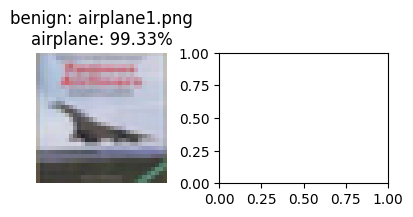

In [11]:
import matplotlib.pyplot as plt

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10, 20))
cnt = 0
for i, cls_name in enumerate(classes):
    path = f'{cls_name}/{cls_name}1.png'
    # benign image
    cnt += 1
    plt.subplot(len(classes), 4, cnt)
    im = Image.open(f'./data/{path}')
    logit = model(transform(im).unsqueeze(0).to(device))[0]
    predict = logit.argmax(-1).item()
    prob = logit.softmax(-1)[predict].item()
    plt.title(f'benign: {cls_name}1.png\n{classes[predict]}: {prob:.2%}')
    plt.axis('off')
    plt.imshow(np.array(im))
    # adversarial image
    cnt += 1
    plt.subplot(len(classes), 4, cnt)
    im = Image.open(f'./fgsm/{path}')
    logit = model(transform(im).unsqueeze(0).to(device))[0]
    predict = logit.argmax(-1).item()
    prob = logit.softmax(-1)[predict].item()
    plt.title(f'adversarial: {cls_name}1.png\n{classes[predict]}: {prob:.2%}')
    plt.axis('off')
    plt.imshow(np.array(im))
plt.tight_layout()
plt.show()

## Report Question
* Make sure you follow below setup: the source model is "resnet110_cifar10", applying the vanilla fgsm attack on `dog2.png`. You can find the perturbed image in `fgsm/dog2.png`.

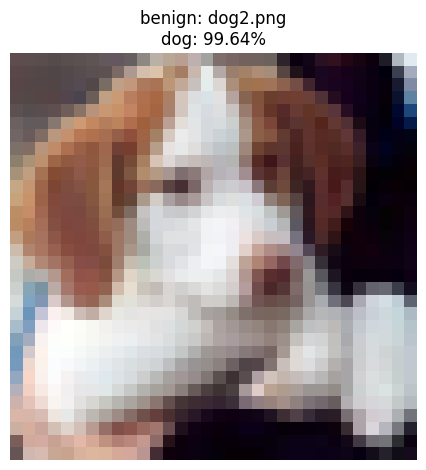

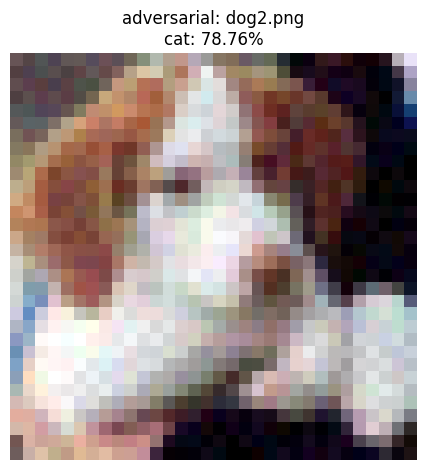

In [18]:
# original image
path = f'dog/dog2.png'
im = Image.open(f'./data/{path}')
logit = model(transform(im).unsqueeze(0).to(device))[0]
predict = logit.argmax(-1).item()
prob = logit.softmax(-1)[predict].item()
plt.title(f'benign: dog2.png\n{classes[predict]}: {prob:.2%}')
plt.axis('off')
plt.imshow(np.array(im))
plt.tight_layout()
plt.show()

# adversarial image
adv_im = Image.open(f'./fgsm/{path}')
logit = model(transform(adv_im).unsqueeze(0).to(device))[0]
predict = logit.argmax(-1).item()
prob = logit.softmax(-1)[predict].item()
plt.title(f'adversarial: dog2.png\n{classes[predict]}: {prob:.2%}')
plt.axis('off')
plt.imshow(np.array(adv_im))
plt.tight_layout()
plt.show()

## Passive Defense - JPEG compression
JPEG compression by imgaug package, compression rate set to 70

Reference: https://imgaug.readthedocs.io/en/latest/source/api_augmenters_arithmetic.html#imgaug.augmenters.arithmetic.JpegCompression

/usr/local/lib/python3.11/dist-packages/imgaug/augmenters/base.py:27: SuspiciousMultiImageShapeWarning: You provided a numpy array of shape (32, 32, 3) as a multi-image augmentation input, which was interpreted as (N, H, W). The last dimension however has value 1 or 3, which indicates that you provided a single image with shape (H, W, C) instead. If that is the case, you should use e.g. augmenter(image=<your input>) or augment_image(<your input>) -- note the singular 'image' instead of 'imageS'. Otherwise your single input image will be interpreted as multiple images of shape (H, W) during augmentation.
  ia.warn(


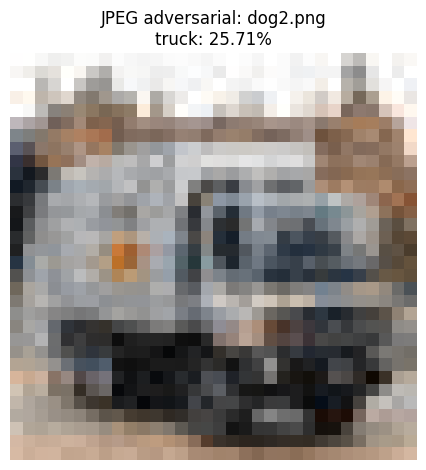

In [36]:
# import imgaug.augmenters as iaa

# # pre-process image
# x = transforms.ToTensor()(im)*255
# x = x.permute(1, 2, 0).numpy()
# compressed_x = x.astype(np.uint8)

# # TODO: use "imgaug" package to perform JPEG compression (compression rate = 70)
# # compressed_x = iaa.JpegCompression(compression=70)
# seq = iaa.Sequential([
#         iaa.JpegCompression(compression=70)
#     ])
# compressed_x = seq(images=compressed_x)

# logit = model(transform(compressed_x).unsqueeze(0).to(device))[0]
# predict = logit.argmax(-1).item()
# prob = logit.softmax(-1)[predict].item()
# plt.title(f'JPEG adversarial: dog2.png\n{classes[predict]}: {prob:.2%}')
# plt.axis('off')


# plt.imshow(compressed_x)
# plt.tight_layout()
# plt.show()

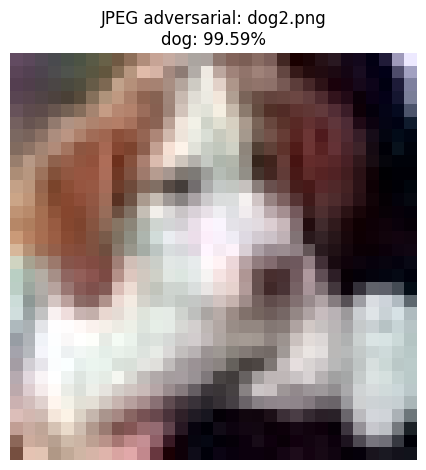

In [19]:
import cv2

def compress_jpeg(image_array, quality=70):
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality]
    _, encoded = cv2.imencode('.jpg', image_array, encode_param)
    decoded = cv2.imdecode(encoded, cv2.IMREAD_COLOR)
    return decoded

# pre-process image
x = transforms.ToTensor()(im)*255
x = x.permute(1, 2, 0).numpy()
x = x.astype(np.uint8)

# TODO: use "imgaug" package to perform JPEG compression (compression rate = 70)
compressed_x = compress_jpeg(x)

logit = model(transform(compressed_x).unsqueeze(0).to(device))[0]
predict = logit.argmax(-1).item()
prob = logit.softmax(-1)[predict].item()
plt.title(f'JPEG adversarial: dog2.png\n{classes[predict]}: {prob:.2%}')

plt.axis('off')

plt.imshow(compressed_x)
plt.tight_layout()
plt.show()